## Weather version 2.0 (version 1 died in the sandbox)
Cathal Redmond 14 Dec 2025 (ho ho ho)

In [381]:
# define imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime



In [382]:
# Define the location of the file. 
# I will attempt to load in the larger hourly file correctly first and see if i can make it to be small enough to upload to the github location. 

url = "https://cli.fusio.net/cli/climate_data/webdata/hly4935.csv"

# define the columns to use as a list 
col_list = [0,4,12,14]

#Read the data from the URL and assign it into a dataframe "df"
df = pd.read_csv(url, 
                 usecols = col_list, 
                 skiprows = 24, 
                 names = ('date_and_time','temperature','windspeed','winddir')
                 )

# display information / details about the dataframe 
df.info()

# Show some of the data to check its form
df.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 257154 entries, 0 to 257153
Data columns (total 4 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   date_and_time  257154 non-null  object 
 1   temperature    257154 non-null  float64
 2   windspeed      257154 non-null  object 
 3   winddir        257154 non-null  object 
dtypes: float64(1), object(3)
memory usage: 7.8+ MB


C:\Users\catha\AppData\Local\Temp\ipykernel_15980\383256177.py:10: DtypeWarning: Columns (12,14) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(url,


,date_and_time,temperature,windspeed,winddir
0,10-apr-1996 14:00,11.5,0,0
1,31-jul-1996 08:00,11.5,0,0
2,31-jul-1996 09:00,11.6,0,0


In [383]:
# format the data into desired types
df['date_and_time'] = pd.to_datetime(df['date_and_time'],format='mixed')
df['date'] = df['date_and_time'].dt.strftime('%Y %m %d')
df['time'] = df['date_and_time'].dt.strftime('%H:%M')
df['month'] = df['date_and_time'].dt.strftime('%m')

print("Datetime data is of type: ",type(datetime))

# display information / details about the dataframe 
df.info()

# Show some of the data to check its form
df.head(3)


Datetime data is of type:  <class 'type'>
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 257154 entries, 0 to 257153
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   date_and_time  257154 non-null  datetime64[ns]
 1   temperature    257154 non-null  float64       
 2   windspeed      257154 non-null  object        
 3   winddir        257154 non-null  object        
 4   date           257154 non-null  object        
 5   time           257154 non-null  object        
 6   month          257154 non-null  object        
dtypes: datetime64[ns](1), float64(1), object(5)
memory usage: 13.7+ MB


,date_and_time,temperature,windspeed,winddir,date,time,month
0,1996-04-10 14:00:00,11.5,0,0,1996 04 10,14:00,04
1,1996-07-31 08:00:00,11.5,0,0,1996 07 31,08:00,07
2,1996-07-31 09:00:00,11.6,0,0,1996 07 31,09:00,07


<Axes: xlabel='date_and_time'>

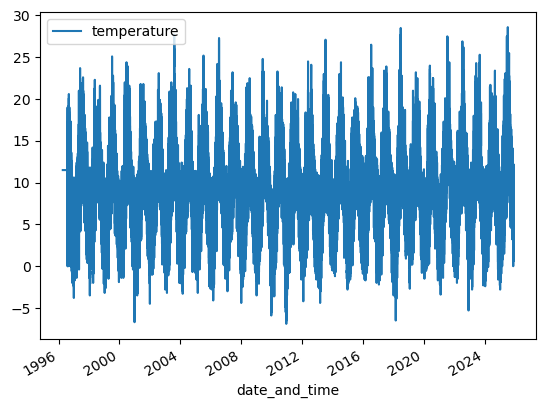

In [384]:
# Create a plot showing the temperature data over time

df.plot('date_and_time','temperature')

In [385]:
# calculate the mean temperature for each day
# we will use the pivot table method to achieve this task

MeanTemp = pd.pivot_table(df,'temperature', 'date', aggfunc='mean')
print(type(MeanTemp)) # shows the dataframe
MeanTemp.head(3)



<class 'pandas.core.frame.DataFrame'>


,temperature
date,
1996 04 10,11.500000
1996 07 31,12.650000
1996 08 01,11.666667


<Axes: title={'center': 'Mean Temperature by Date'}, xlabel='date'>

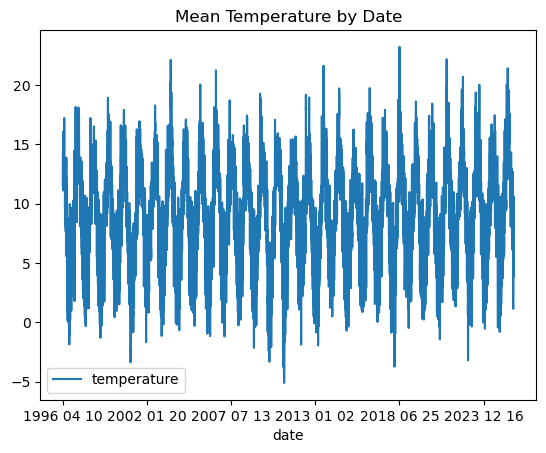

In [386]:
# plot the mean temperature graph also
MeanTemp.plot(kind = 'line',title = 'Mean Temperature by Date')

In [387]:
# calcuate the average temperature for each month 
# (I am assuming this is the average temperature per month for all years pooled)

MonthTemp = pd.pivot_table(df,'temperature', 'month', aggfunc='mean')
print(type(MonthTemp)) # shows the dataframe
MonthTemp.head(20)

<class 'pandas.core.frame.DataFrame'>


,temperature
month,
01,4.328953
02,4.699166
03,5.679973
04,7.597912
05,10.288042
06,12.403602
07,13.699287
08,13.615175
09,12.068245


<function matplotlib.pyplot.show(close=None, block=None)>

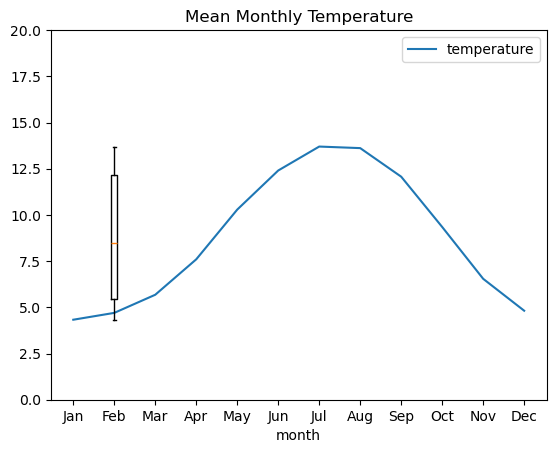

In [388]:
# plot the mean temperature per monyh graph
MonthTemp.plot(kind = 'line',title = 'Mean Monthly Temperature')

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.boxplot(MonthTemp)
#plt.title(title="Mean Monthly Temperature")
#plt.xlabel("Month Name")
#plt.ylabel("Degrees Celcius")
plt.ylim(0,20)
plt.xticks(np.arange(12), months)
plt.show

In [389]:
# Convert the windspeed data into floating point format
# replace empty or error data with interpolated data from the surrounding data. in this case, we have chosen to use linear interpertation for this task 
df['windspeed'] = df['windspeed'].interpolate(method='linear')
df['windspeed'] = df['windspeed'].astype('float',errors='ignore')
print(df['windspeed'].describe())
print(df['windspeed'])
df.head(5)

count     257154
unique        91
top            6
freq       18193
Name: windspeed, dtype: int64
0          0
1          0
2          0
3          0
4          0
          ..
257149    17
257150    14
257151    10
257152     6
257153     8
Name: windspeed, Length: 257154, dtype: object


C:\Users\catha\AppData\Local\Temp\ipykernel_15980\178075045.py:3: FutureWarning: Series.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df['windspeed'] = df['windspeed'].interpolate(method='linear')


,date_and_time,temperature,windspeed,winddir,date,time,month
0,1996-04-10 14:00:00,11.5,0,0,1996 04 10,14:00,04
1,1996-07-31 08:00:00,11.5,0,0,1996 07 31,08:00,07
2,1996-07-31 09:00:00,11.6,0,0,1996 07 31,09:00,07
3,1996-07-31 10:00:00,12.9,0,0,1996 07 31,10:00,07
4,1996-07-31 11:00:00,14.5,0,0,1996 07 31,11:00,07


## Going for the big scores: lets tackle them windspeed graphs


In [390]:
# ensure windspeed is numeric, coerce non-numeric to NaN then interpolate
df['windspeed'] = pd.to_numeric(df['windspeed'], errors='coerce')
df['windspeed'] = df['windspeed'].interpolate(method='linear')

df['winddir'] = pd.to_numeric(df['winddir'], errors='coerce')
df['winddir'] = df['winddir'].interpolate(method='linear')



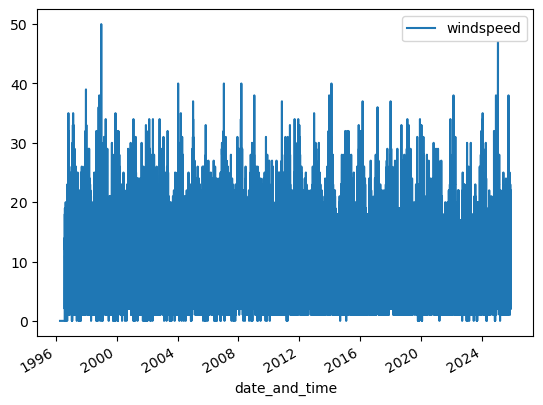

In [391]:
# now plot

df.plot('date_and_time', 'windspeed')
plt.xlabel='date_and_time'
plt.ylabel=("Windspeed")
plt.title=("Windspeed over Time")


In [392]:
# calculate the mean windspeed for each day
MeanWind = pd.pivot_table(df,'windspeed', 'date', aggfunc='mean')
print(type(MeanWind)) # shows the dataframe
MeanWind.head(3)


<class 'pandas.core.frame.DataFrame'>


,windspeed
date,
1996 04 10,0.000
1996 07 31,0.000
1996 08 01,9.875


<function matplotlib.pyplot.show(close=None, block=None)>

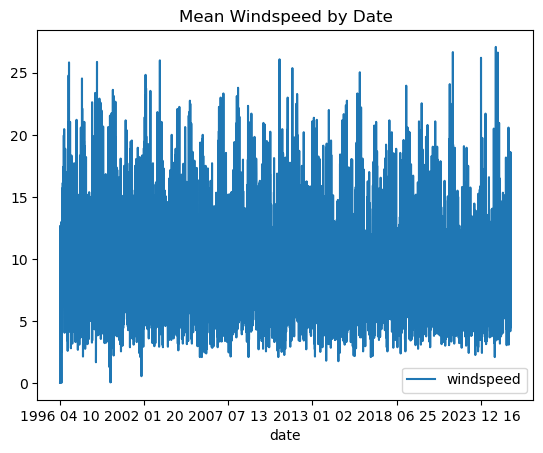

In [393]:
# plot the mean windspeed graph also
MeanWind.plot(kind = 'line',title = 'Mean Windspeed by Date')
plt.xlabel='date_and_time'
plt.ylabel='windspeed'
plt.title=("Mean Windspeed by Date")
plt.show

In [394]:
# calcuate the maximum windspeed for each day
MaxDailyWind = pd.pivot_table(df,'windspeed', 'date', aggfunc='max')
MaxDailyWind = MaxDailyWind.reset_index(drop=False)
print(type(MaxDailyWind)) # shows the dataframe
MaxDailyWind.head(3)

<class 'pandas.core.frame.DataFrame'>


,date,windspeed
0,1996 04 10,0.0
1,1996 07 31,0.0
2,1996 08 01,14.0


<function matplotlib.pyplot.show(close=None, block=None)>

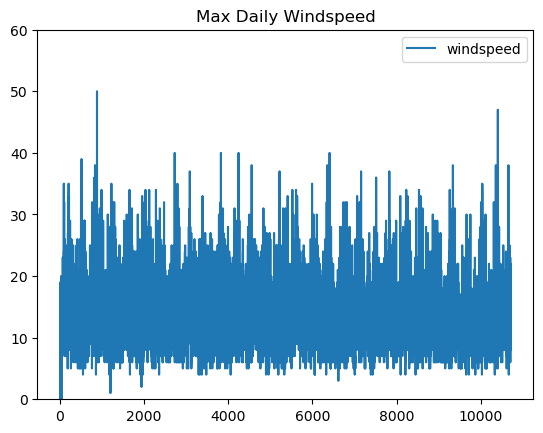

In [395]:
# plot the mean windspeed per month graph
MaxDailyWind.plot(kind = 'line',title = 'Max Daily Windspeed')
plt.title=("Max Daily Windspeed")
plt.xlabel=("Month Name")
plt.ylabel=("Windspeed (knots)")
plt.ylim(0,60)
plt.show

In [396]:
print(MaxDailyWind)
MaxDailyWind.info()

             date  windspeed
0      1996 04 10        0.0
1      1996 07 31        0.0
2      1996 08 01       14.0
3      1996 08 02       13.0
4      1996 08 03       10.0
...           ...        ...
10712  2025 11 27       22.0
10713  2025 11 28       19.0
10714  2025 11 29       12.0
10715  2025 11 30       19.0
10716  2025 12 01        8.0

[10717 rows x 2 columns]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10717 entries, 0 to 10716
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   date       10717 non-null  object 
 1   windspeed  10717 non-null  float64
dtypes: float64(1), object(1)
memory usage: 167.6+ KB


In [397]:
# Monthly mean of max daily windspeed
MonthlyMaxWind = pd.pivot_table(MaxDailyWind,'windspeed', 'date', aggfunc='mean')
MonthlyMaxWind = MonthlyMaxWind.reset_index(drop=False)
print(type(MonthlyMaxWind)) # shows the dataframe
MonthlyMaxWind.head(3)

<class 'pandas.core.frame.DataFrame'>


,date,windspeed
0,1996 04 10,0.0
1,1996 07 31,0.0
2,1996 08 01,14.0


In [398]:
# format the data into desired types
MonthlyMaxWind['date'] = pd.to_datetime(MonthlyMaxWind['date'],format='mixed')
MonthlyMaxWind['month'] = MonthlyMaxWind['date'].dt.strftime('%m')
MonthlyMaxWind.drop(columns=['date'],inplace=True)
print(MonthlyMaxWind)


       windspeed month
0            0.0    04
1            0.0    07
2           14.0    08
3           13.0    08
4           10.0    08
...          ...   ...
10712       22.0    11
10713       19.0    11
10714       12.0    11
10715       19.0    11
10716        8.0    12

[10717 rows x 2 columns]


In [401]:
MonthlyMaxWind = pd.pivot_table(MonthlyMaxWind,'windspeed', 'month', aggfunc='mean')
MonthlyMaxWind = MonthlyMaxWind.reset_index(drop=False)
print(type(MonthlyMaxWind)) # shows the dataframe
MonthlyMaxWind.head(12)

<class 'pandas.core.frame.DataFrame'>


,month,windspeed
0,01,16.034483
1,02,16.706960
2,03,15.301446
3,04,14.142365
4,05,13.671858
5,06,13.093103
6,07,12.493333
7,08,12.898925
8,09,13.491111
9,10,14.516129


<function matplotlib.pyplot.show(close=None, block=None)>

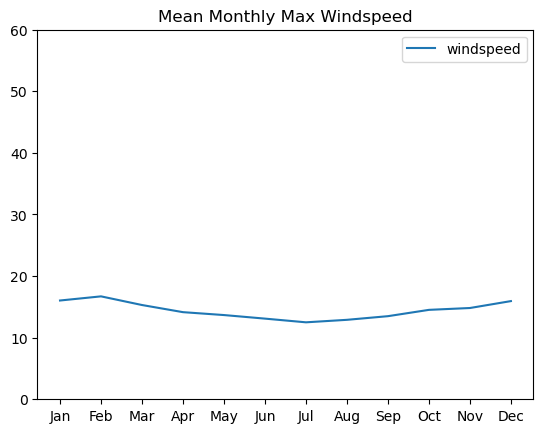

In [402]:
# plot the mean windspeed per month graph
MonthlyMaxWind.plot(kind = 'line',title = 'Mean Monthly Max Windspeed')
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.ylim(0,60)
plt.xticks(np.arange(12), months)
plt.show

## Wind Direction

In [ ]:
# Now we will look at wind direction data
df['winddir'] = df['winddir'].interpolate(method='linear')
df['winddir'] = df['winddir'].astype('float',errors='ignore')
print(df['winddir'].describe()) 
print(type(df['winddir']))
df.head(5)

count    257154.000000
mean        207.046322
std          84.879101
min           0.000000
25%         150.000000
50%         210.000000
75%         270.000000
max         360.000000
Name: winddir, dtype: float64
<class 'pandas.core.series.Series'>


,date_and_time,temperature,windspeed,winddir,date,time,month
0,1996-04-10 14:00:00,11.5,0.0,0.0,1996 04 10,14:00,04
1,1996-07-31 08:00:00,11.5,0.0,0.0,1996 07 31,08:00,07
2,1996-07-31 09:00:00,11.6,0.0,0.0,1996 07 31,09:00,07
3,1996-07-31 10:00:00,12.9,0.0,0.0,1996 07 31,10:00,07
4,1996-07-31 11:00:00,14.5,0.0,0.0,1996 07 31,11:00,07


<Axes: title={'center': 'Wind Direction over Time'}, xlabel='date_and_time'>

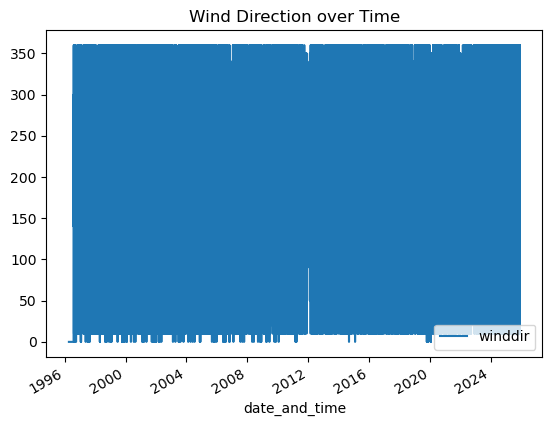

In [ ]:
# plot wind direction over time - at the moment i am not sure how to make this plot more readable, as wind direction is circular data from 0 to 360 degrees. 
df.plot('date_and_time','winddir', title='Wind Direction over Time')

In [ ]:
# calculate the mean wind direction for each day
MeanWindDir = pd.pivot_table(df,'winddir', 'date', aggfunc='mean')
print(type(MeanWindDir)) # shows the dataframe
MeanWindDir.head(3)

<class 'pandas.core.frame.DataFrame'>


,winddir
date,
1996 04 10,0.000
1996 07 31,0.000
1996 08 01,253.125


<Axes: title={'center': 'Mean Wind Direction by Date'}, xlabel='date'>

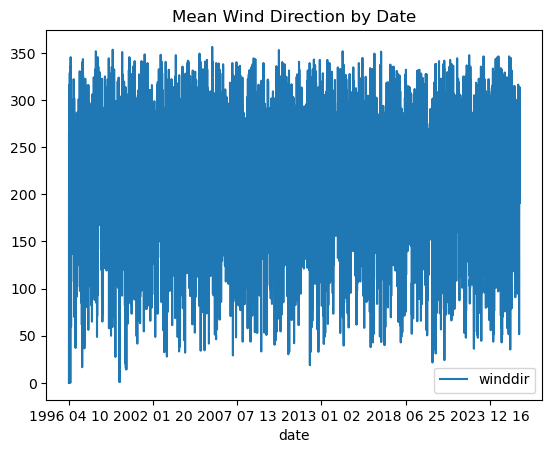

In [ ]:
# plot the mean wind direction graph also
MeanWindDir.plot(kind = 'line',title = 'Mean Wind Direction by Date')

In [ ]:
# calcuate the average wind direction for each month    
MonthWindDir = pd.pivot_table(df,'winddir', 'month', aggfunc='mean')
print(type(MonthWindDir)) # shows the dataframe
MonthWindDir.head(3)

<class 'pandas.core.frame.DataFrame'>


,winddir
month,
01,205.451891
02,203.894994
03,197.881674


<function matplotlib.pyplot.show(close=None, block=None)>

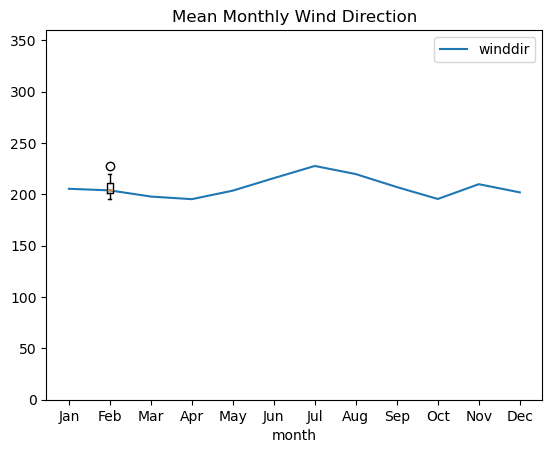

In [ ]:
# plot the mean wind direction per month graph
MonthWindDir.plot(kind = 'line',title = 'Mean Monthly Wind Direction')
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.boxplot(MonthWindDir)
plt.title=("Mean Monthly Wind Direction")
plt.xlabel=("Month Name")
plt.ylabel=("Wind Direction (degrees)")
plt.ylim(0,360)
plt.xticks(np.arange(12), months)
plt.show


## End of code
Cathal Redmond 14 Dec 2025


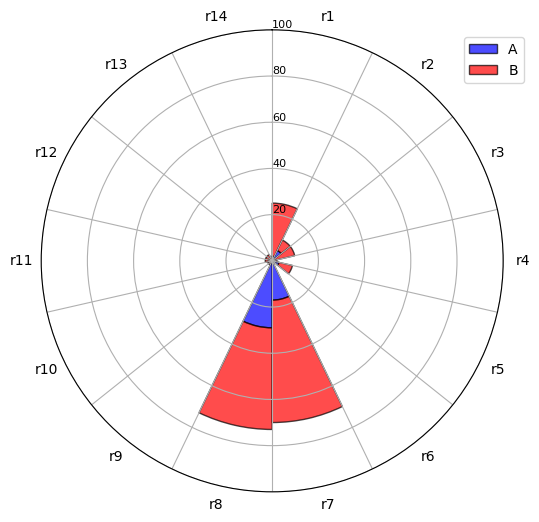

In [ ]:
## do not use the following code - just kept for reference
## try plot this as Radar Pie plot, or POLAR plot. 
# i would like to try this as an alternative visualisation - trying to adapt code from:
# https://stackoverflow.com/questions/62938954/pie-radar-chart-in-python-pizza-slices 

# i would need to define what my cardinal directions are and how to group the wind direction data accordingly.
# then i would need to aggregate the windspeed data accordingly and cast it into each directon group. 

import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator
import pandas as pd
from math import pi
import numpy as np

df = pd.DataFrame({'group': ['A', 'B'], 'r1': [2, 23], 'r2': [5, 5], 'r3': [1, 9], 'r4': [1, 1], 'r5': [3, 6], 'r6': [0, 0], 'r7': [17, 53], 'r8': [29, 44], 'r9': [0, 2], 'r10': [0, 2], 'r11': [0, 3], 'r12': [1, 2], 'r13': [0, 3], 'r14': [0, 0], })

categories = list(df)[1:]
N = len(categories)
angles = np.linspace(0, 2 * pi, N, endpoint=False)
angles_mids = angles + (angles[1] / 2)

fig = plt.figure(figsize=(6, 6))
ax = plt.subplot(111, polar=True)
ax.set_theta_offset(pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles_mids)
ax.set_xticklabels(categories)
ax.xaxis.set_minor_locator(FixedLocator(angles))

# Draw ylabels
ax.set_rlabel_position(0)
ax.set_yticks([20, 40, 60, 80, 100])
ax.set_yticklabels(["20", "40", "60", "80", "100"], color="black", size=8)
ax.set_ylim(0, 100)

values0 = df.loc[0].drop('group').values
ax.bar(angles_mids, values0, width=angles[1] - angles[0],
       facecolor='b', alpha=0.7, edgecolor='k', linewidth=1, label="A")

values1 = df.loc[1].drop('group').values
ax.bar(angles_mids, values1, bottom=values0, width=angles[1] - angles[0],
       facecolor='r', alpha=0.7, edgecolor='k', linewidth=1, label="B")

ax.grid(True, axis='x', which='minor')
ax.grid(False, axis='x', which='major')
ax.grid(True, axis='y', which='major')
ax.legend(loc='upper left', bbox_to_anchor=(0.9, 1))
plt.show()
